<!-- DE-STEP-HEADER -->
## 🧭 DE Pipeline Step 3/13 — จำแนก Operating State (Time Alignment & Operating Modes)

**สถานะ:** ✅ ใช้งานจริง — `CHAIN[2]` ใน `pipeline/run_all.py`, ตามด้วย hook อัตโนมัติ
`pipeline/compute_fouling_rate.py` (ไม่ใช่ notebook แต่รันต่อทันที — ดูข้อควรระวังด้านล่าง)

**ตอบคำถามอะไร:** หาว่าวันไหน shell ไหนของแต่ละ HX กำลังทำงานจริง (E113A↔E112C สลับกัน,
E101EF↔E101G spare-shell ไม่มี sensor) กันข้อมูลปนกันข้าม HX

**Input:** `Feature_calculated.csv` (จาก step 2)

**Output:** `Operating_State.csv` → step 4 ใช้ต่อ, และ **`pipeline/compute_fouling_rate.py` อ่านต่อทันที**
เพื่อคำนวณ fouling rate แบบ robust (Theil-Sen, กรอง in-service state) เขียนทับ `Fouling_Rate_By_Run.csv`
— **นี่คือ fouling rate ตัวจริงที่ทุกอย่างต้องใช้** ไม่ใช่เลขจาก step 2

**แดชบอร์ด:** ไม่แสดงผลตรง ๆ — เป็น input ให้ step ถัดไปและ hook ด้านบน

**Requirements ที่เกี่ยวข้อง:** FR-PM-* (Process Mode Identification §2.3)

อ้างอิงเพิ่มเติม: `docs/ANALYSIS_PIPELINE_GUIDE.md` §1 (แถวที่ 3 และ 3.5)

---


# 2a. Operating-State Classification -- CPHT-1 / CPHT-2

**Purpose:** before any Q/fouling/CIT modeling, establish -- for every day and every
heat exchanger -- which physical unit was actually carrying the duty. The crude
preheat train (CPHT) uses parallel/spare shells and shared piping, so a given
crude-side "position" in the train (e.g. "E113/CIT stage") can be served by
different physical equipment on different days. Feeding raw tag values into a
Q or fouling model without first resolving this will silently mix two different
pieces of equipment's fouling history into one column.

**Train structure (per plant configuration):**
- **CPHT-1** -- `E101AB, E101CD, E101EF, E101G, E102` -- preheats crude ahead of the
  desalter. E101G is a manual/hand-valved spare shell with **no dedicated
  instrumentation** in the historian -- it must be inferred, not read directly.
- **CPHT-2** -- `E106AB, E110ABC, E103AB, E107AB, E111, E104, E108AB, E112AB,
  E105AB, E112C, E109AB, E113A` -- the series chain that raises CIT ahead of the
  furnace. This is where furnace duty/energy and tube-metal-life impact live.

**Operating cases handled here:**
1. CPHT-1 / E101EF <-> E101G swap (crude total charge unaffected, E101EF flow -> 0,
   E101G carries the difference but is unmeasured)
2. CPHT-2 residue chain E113A <-> E112C (E113C in field) parallel-spare swap,
   feeding E112AB -> E108AB in series
3. E112AB cleaning -- residue routed to bypass E112AB (both E113A & E112C running
   simultaneously feeding E108AB directly)

**Note on an earlier (wrong) assumption:** a prior working note in this project
had it that the *lower* of `1TI117.pv` / `1TI117B.pv` was the active E113/E112C
shell. Checking real data below shows the opposite: the **idle/standby shell
sits near-ambient (~30-40C)** while the **in-service shell tracks close to the
C101 BTM residue source temperature (`1TI161.pv`, ~330C)**. So the *higher*
reading is the active one -- corrected here and in project memory.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

FILEPATH = r'C:\Desktop\Bangchak Internship 2026\Data\Process_information_with_crude.csv'
df = pd.read_csv(FILEPATH, index_col=0, parse_dates=True)

FIG_DIR = r'C:\Desktop\Bangchak Internship 2026\furnace-optimization\figures\features'
os.makedirs(FIG_DIR, exist_ok=True)

print(f'Shape: {df.shape}')
print(f'Date range: {df.index.min().date()} to {df.index.max().date()}')

Shape: (1898, 103)
Date range: 2021-01-01 to 2026-07-01


In [2]:
# -- Systematic data-quality gate (shared nb_audit toolkit) --
import nb_audit as A
_ = A.data_quality_report(df, name='process cleaned', show=True)

── Data-quality report: process cleaned ──
   rows=1898  cols=103  duplicate_rows=0  time_gaps>D=3


---
## 1. CPHT Group Definitions

Single source of truth for train membership -- downstream notebooks (2b/2c/2d)
should import this rather than redefine their own copy (a stale copy of the
E112C tag mapping was already found and fixed once in `01_data_cleaning.ipynb`
-- duplicated config is exactly how that kind of bug creeps back in).

In [3]:
import sys
sys.path.append('C:/Desktop/Bangchak Internship 2026/furnace-optimization/notebooks')
from cpht_config import CPHT_1_HX, CPHT_2_HX

print(f'CPHT-1 (pre-desalter): {len(CPHT_1_HX)} HX -> {CPHT_1_HX}')
print(f'CPHT-2 (pre-furnace / CIT train): {len(CPHT_2_HX)} HX -> {CPHT_2_HX}')

CPHT-1 (pre-desalter): 5 HX -> ['E101AB', 'E101CD', 'E101EF', 'E101G', 'E102']
CPHT-2 (pre-furnace / CIT train): 12 HX -> ['E106AB', 'E110ABC', 'E103AB', 'E107AB', 'E111', 'E104', 'E108AB', 'E112AB', 'E105AB', 'E112C', 'E109AB', 'E113A']


---
## 2. CPHT-1 -- E101 Family: Branch Flows & E101G Inference

`E101AB`, `E101CD`, `E101EF` each have a dedicated crude-flow meter
(`1FI007/008/009.pv`). `E101G` does not -- its tags (`1FI085/086.pv`,
`1HC015/016.pv`, `1TI015.pv`) exist in the plant tag list but are **not present
in the historian export**, confirming it is a manually-valved, unmonitored spare.

**Detection approach:**
- A branch is **OFF** on a given day if its own flow reads ~0.
- When a branch is OFF but **total crude charge is unchanged**, the missing flow
  must be going through the untracked spare (E101G) -- inferred via a mass
  balance: `Flow_G_inferred = total_charge - (FI007 + FI008 + FI009)`.

In [4]:
FLOW_OFF_THRESH = 10.0  # m3/hr -- below this, branch is considered not flowing

branch_flow = df[['1FI007.pv', '1FI008.pv', '1FI009.pv']].rename(
    columns={'1FI007.pv': 'E101AB', '1FI008.pv': 'E101CD', '1FI009.pv': 'E101EF'})
total_charge = df['1fi005.pv']

branch_off = branch_flow < FLOW_OFF_THRESH
flow_G_inferred = total_charge - branch_flow.sum(axis=1)

# E101G considered in service if any branch is off AND the mass-balance gap is
# large enough to be a real flow diversion (not just noise/measurement error)
G_ACTIVE_THRESH = 30.0  # m3/hr
e101g_active = branch_off.any(axis=1) & (flow_G_inferred > G_ACTIVE_THRESH)

print('Branch OFF day counts:')
print(branch_off.sum())
print(f'\nE101G inferred active: {e101g_active.sum()} / {len(df)} days')
print(f'E101G inferred flow (active days): mean {flow_G_inferred[e101g_active].mean():.1f} m3/hr, '
      f'range {flow_G_inferred[e101g_active].min():.1f}-{flow_G_inferred[e101g_active].max():.1f} m3/hr')

Branch OFF day counts:
E101AB      0
E101CD      0
E101EF    165
dtype: int64

E101G inferred active: 165 / 1898 days
E101G inferred flow (active days): mean 275.5 m3/hr, range 257.6-309.7 m3/hr


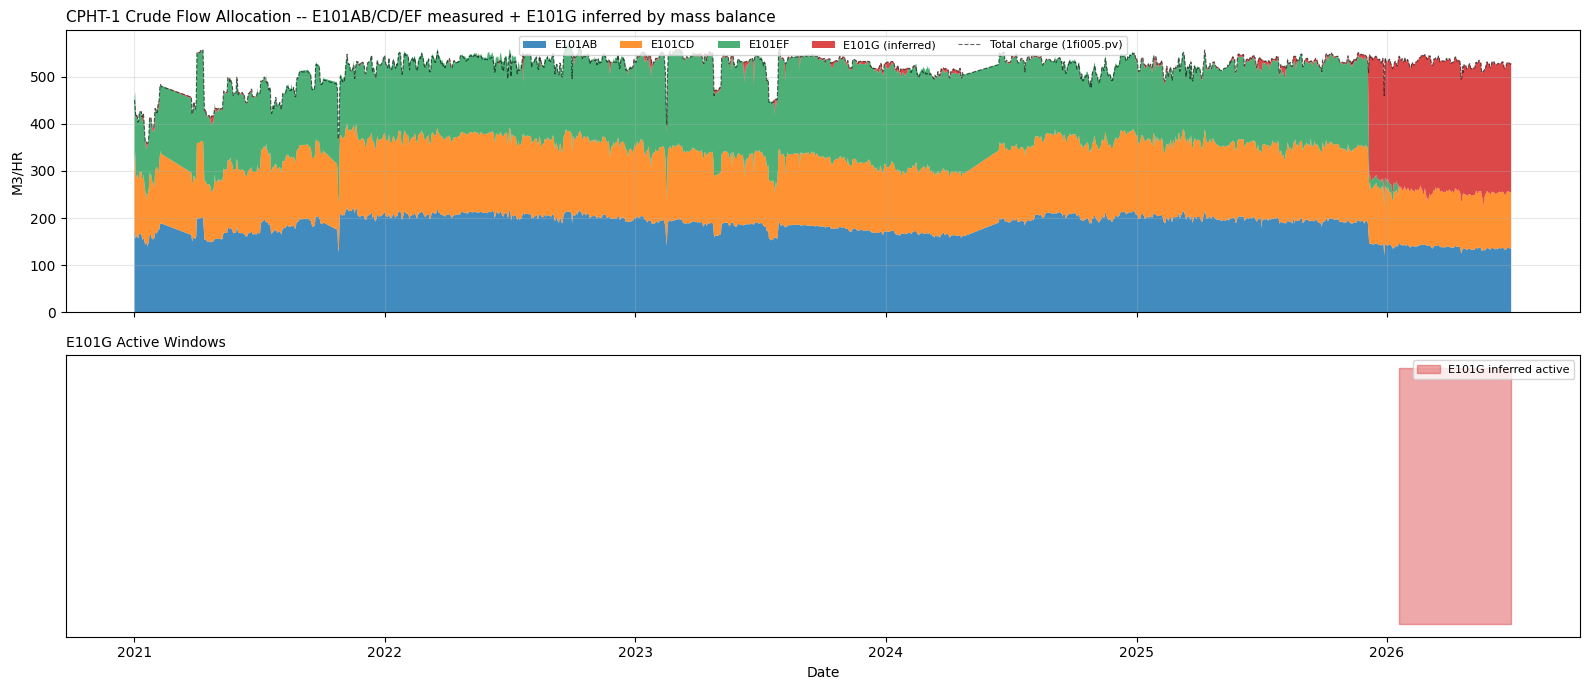

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

axes[0].stackplot(df.index, branch_flow['E101AB'], branch_flow['E101CD'], branch_flow['E101EF'],
                   flow_G_inferred.clip(lower=0),
                   labels=['E101AB', 'E101CD', 'E101EF', 'E101G (inferred)'],
                   colors=['#1f77b4', '#ff7f0e', '#2ca25f', '#d62728'], alpha=0.85)
axes[0].plot(df.index, total_charge, color='black', linewidth=0.8, linestyle='--',
             label='Total charge (1fi005.pv)', alpha=0.6)
axes[0].set_ylabel('M3/HR')
axes[0].set_title('CPHT-1 Crude Flow Allocation -- E101AB/CD/EF measured + E101G inferred by mass balance',
                   fontsize=11, loc='left')
axes[0].legend(fontsize=8, ncol=5, loc='upper center')
axes[0].grid(True, alpha=0.3)

axes[1].fill_between(df.index, 0, 1, where=e101g_active, color='#d62728', alpha=0.4,
                      step='mid', label='E101G inferred active')
axes[1].set_yticks([])
axes[1].set_xlabel('Date')
axes[1].set_title('E101G Active Windows', fontsize=10, loc='left')
axes[1].legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '2a_cpht1_e101g_inference.png'), bbox_inches='tight')
plt.show()

### 2.1 Diagnostic (not gating) -- does E101G's substitution disturb E101AB/E101CD?

**Why this exists:** `state['E101AB']`/`state['E101CD']` above are set `NORMAL`
for the entire dataset except their own zero-flow days -- neither is ever
flagged during an `e101g_active` window, even though E101AB shares its
cold-inlet tag (`1TI102.pv`) with E101EF (see `cpht_config.HX_CONFIG`). If the
three-way flow split among E101AB/E101CD/E101EF shifts when E101G comes
online, E101AB's own Q/dT could show a level change that
`08_cleaning_priority_ranking.ipynb` would read as a genuine fouling trend
(its `worsening`/`trajectory_multiplier` term), not a topology artifact.

**This cell is diagnostic only** -- same convention as
`pipeline/compute_fouling_rate.py`'s `_hot_cold_balance_diagnostic`: it does
not write any file and does not change `state` above. It exists so an
engineer can look at the actual before/during/after numbers and confirm or
reject the hypothesis before anyone changes the masking logic. See the open
item in `docs/UNRESOLVED_ENGINEERING_DECISIONS.md` §2.

In [6]:
# Diagnostic-only Q/dT_cold for E101AB and E101CD (the two CPHT-1 siblings that
# share E101EF's cold-inlet tag 1TI102.pv), using the same Watson-Nelson Cp /
# Rackett density formula as 04_fouling_rate_estimation.ipynb so results are
# directly comparable to the fouling-rate pipeline that actually consumes this
# data. Not exported anywhere -- see markdown above.
SG = df['SG_15_6C']

def _diag_duty(cold_in_tag, cold_out_tag, flow_col):
    t_in, t_out = df[cold_in_tag], df[cold_out_tag]
    t_avg = (t_in + t_out) / 2
    cp = (1.685 + 0.00339 * t_avg) / np.sqrt(SG)
    rho_156 = SG * 999.016
    alpha = 613.9723 / rho_156 ** 2
    rho_t = rho_156 * np.exp(-alpha * (t_avg - 15.6) * (1 + 0.8 * alpha * (t_avg - 15.6)))
    dT = t_out - t_in
    mdot = df[flow_col] * rho_t / 3600
    Q = mdot * cp * dT
    return dT, Q / total_charge

dT_E101AB, Qnorm_E101AB = _diag_duty('1TI102.pv', '1TI101.pv', '1FI007.pv')
dT_E101CD, Qnorm_E101CD = _diag_duty('1TI102.pv', '1TI104.pv', '1FI008.pv')

# contiguous e101g_active windows (there may be more than one substitution event)
_starts = e101g_active.index[e101g_active & ~e101g_active.shift(1, fill_value=False)]
_ends   = e101g_active.index[e101g_active & ~e101g_active.shift(-1, fill_value=False)]
windows = list(zip(_starts, _ends))
print(f'E101G-active windows: {len(windows)}')

WINDOW_MARGIN = pd.Timedelta(days=30)
rows = []
for w_start, w_end in windows:
    before = df.index[(df.index >= w_start - WINDOW_MARGIN) & (df.index < w_start)]
    during = df.index[(df.index >= w_start) & (df.index <= w_end)]
    after  = df.index[(df.index > w_end) & (df.index <= w_end + WINDOW_MARGIN)]
    for hx, dT_s, Qn_s in [('E101AB', dT_E101AB, Qnorm_E101AB), ('E101CD', dT_E101CD, Qnorm_E101CD)]:
        for phase, idx in [('before', before), ('during', during), ('after', after)]:
            rows.append(dict(window=f'{w_start.date()}..{w_end.date()}', HX=hx, phase=phase,
                              n_days=len(idx),
                              median_dT_cold=round(dT_s.reindex(idx).median(), 2),
                              median_Q_norm=round(Qn_s.reindex(idx).median(), 3)))

diag_df = pd.DataFrame(rows)
print('\nE101AB/E101CD dT_cold and Q_norm around each E101G-active window '
      '(look for a level shift between "before" and "during" -- that would support '
      'the topology-contamination theory; roughly equal values would reject it):')
diag_df

E101G-active windows: 1

E101AB/E101CD dT_cold and Q_norm around each E101G-active window (look for a level shift between "before" and "during" -- that would support the topology-contamination theory; roughly equal values would reject it):


,window,HX,phase,n_days,median_dT_cold,median_Q_norm
0,2026-01-18..2026-07-01,E101AB,before,30,51.39,6.343
1,2026-01-18..2026-07-01,E101AB,during,165,48.43,5.736
2,2026-01-18..2026-07-01,E101AB,after,0,NaN,NaN
3,2026-01-18..2026-07-01,E101CD,before,30,51.47,5.325
4,2026-01-18..2026-07-01,E101CD,during,165,48.94,5.011
5,2026-01-18..2026-07-01,E101CD,after,0,NaN,NaN


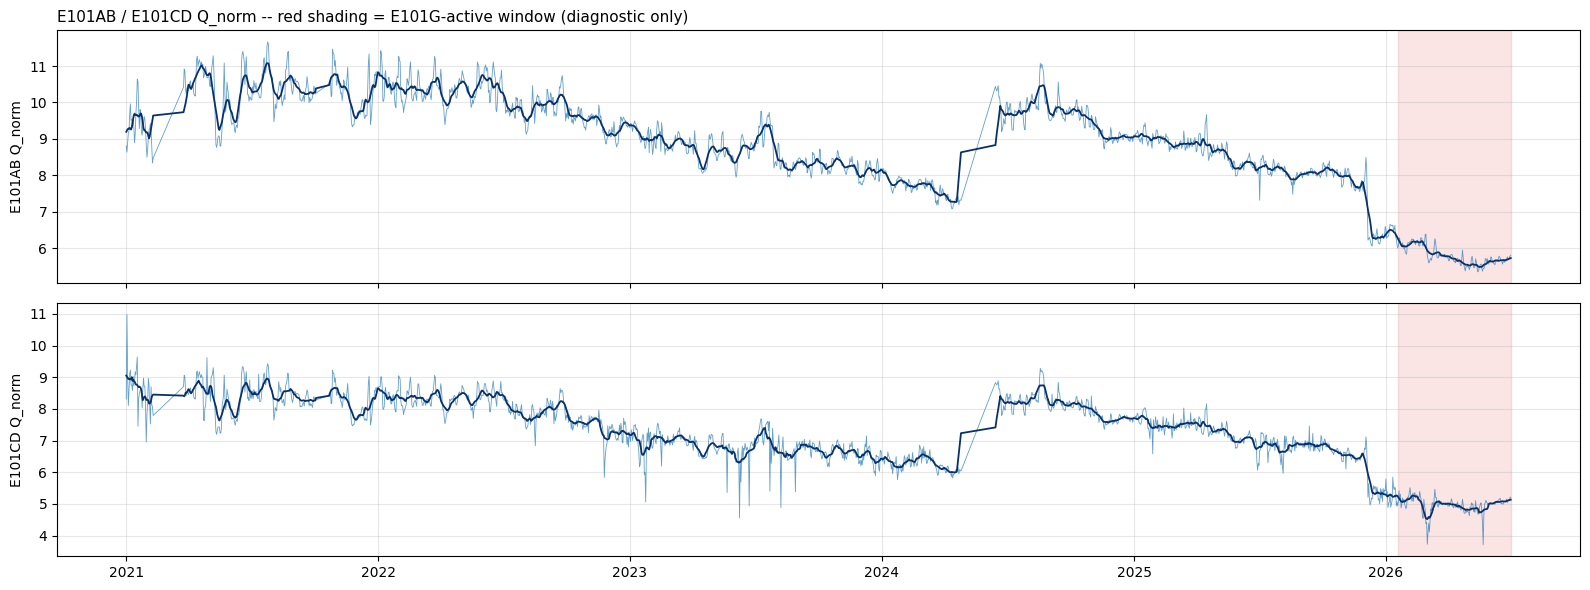

In [7]:
# -- plot: same diagnostic, visual form --
fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)
for ax, (hx, Qn_s) in zip(axes, [('E101AB', Qnorm_E101AB), ('E101CD', Qnorm_E101CD)]):
    ax.plot(Qn_s.index, Qn_s, linewidth=0.6, alpha=0.7, color='#1f77b4')
    ax.plot(Qn_s.index, Qn_s.rolling(14, min_periods=5, center=True).mean(), linewidth=1.3, color='#08306b')
    for w_start, w_end in windows:
        ax.axvspan(w_start, w_end, color='#d62728', alpha=0.12)
    ax.set_ylabel(f'{hx} Q_norm')
    ax.grid(True, alpha=0.3)
axes[0].set_title('E101AB / E101CD Q_norm -- red shading = E101G-active window (diagnostic only)',
                   fontsize=11, loc='left')
plt.tight_layout()
plt.show()

---
## 3. CPHT-2 Residue Chain -- E113A / E112C Active-Shell Detection

Residue flows C101 BTM (`1TI161.pv`, source, ~330C) -> **E113A** (outlet
`1TI117.pv`) or **E112C**/field-E113C (outlet `1TI117B.pv`), whichever is in
service -> **E112AB** (outlet `1TI127.pv`) -> **E108AB**.

The idle shell's outlet tag sits near-ambient (no flow, no duty); the active
shell's outlet tracks close to the source temperature. A simple **absolute
temperature threshold** (not a delta) separates the two states reliably.

In [8]:
SHELL_ACTIVE_TEMP_THRESH = 150.0  # degC -- idle shells sit near-ambient, active shells stay well above this

e113a_active = df['1TI117.pv'] > SHELL_ACTIVE_TEMP_THRESH
e112c_active = df['1TI117B.pv'] > SHELL_ACTIVE_TEMP_THRESH

print(f'E113A active:  {e113a_active.sum():4d} / {len(df)} days')
print(f'E112C active:  {e112c_active.sum():4d} / {len(df)} days')
print(f'Both active:   {(e113a_active & e112c_active).sum():4d} days  <- candidate E112AB-bypass / parallel-run window')
print(f'Neither active:{(~e113a_active & ~e112c_active).sum():4d} days  <- should be ~0; flag for review if not')

# Effective residue temp feeding E112AB = whichever shell is actually in service
effective_hot_in_e112ab = df[['1TI117.pv', '1TI117B.pv']].max(axis=1)
dt_e112ab = effective_hot_in_e112ab - df['1TI127.pv']

print(f'\nE112AB residue dT (effective_hot_in - 1TI127.pv): '
      f'mean {dt_e112ab.mean():.1f}, min {dt_e112ab.min():.1f}, max {dt_e112ab.max():.1f}')
print(f'Days with dT < 10 (possible E112AB bypass/near-zero duty): {(dt_e112ab < 10).sum()}')

E113A active:  1710 / 1898 days
E112C active:   387 / 1898 days
Both active:    199 days  <- candidate E112AB-bypass / parallel-run window
Neither active:   0 days  <- should be ~0; flag for review if not

E112AB residue dT (effective_hot_in - 1TI127.pv): mean 73.4, min 1.8, max 263.5
Days with dT < 10 (possible E112AB bypass/near-zero duty): 2


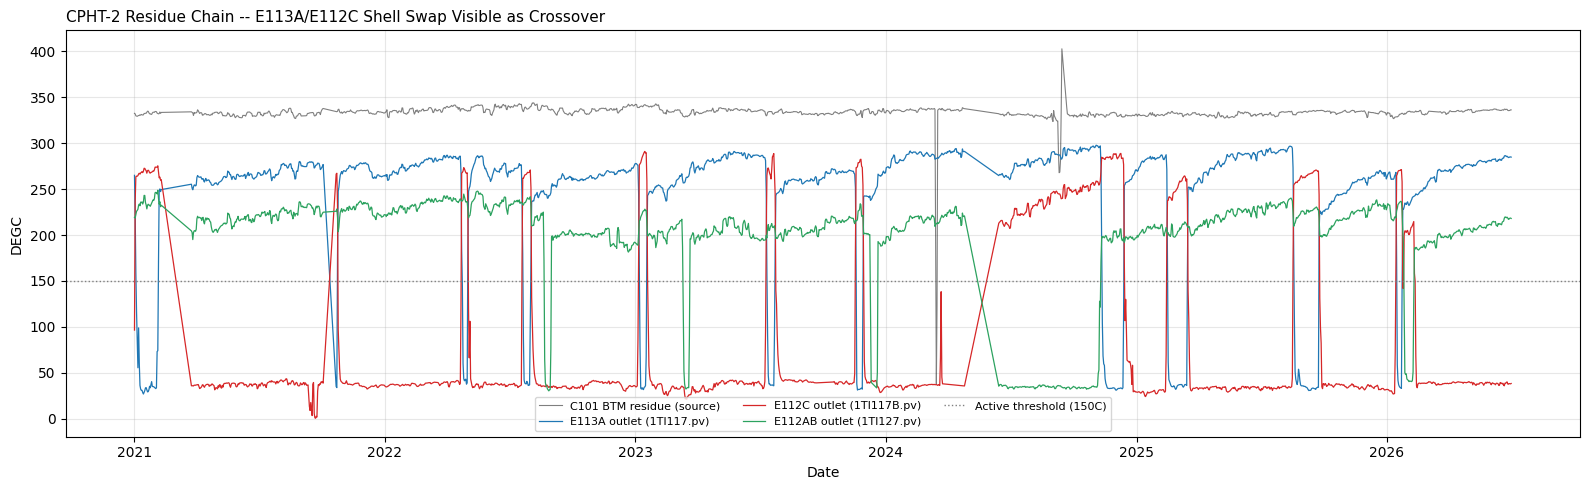

In [9]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df.index, df['1TI161.pv'], color='black', linewidth=0.8, alpha=0.5, label='C101 BTM residue (source)')
ax.plot(df.index, df['1TI117.pv'], color='#1f77b4', linewidth=0.9, label='E113A outlet (1TI117.pv)')
ax.plot(df.index, df['1TI117B.pv'], color='#d62728', linewidth=0.9, label='E112C outlet (1TI117B.pv)')
ax.plot(df.index, df['1TI127.pv'], color='#2ca25f', linewidth=0.9, label='E112AB outlet (1TI127.pv)')
ax.axhline(SHELL_ACTIVE_TEMP_THRESH, color='gray', linestyle=':', linewidth=1, label=f'Active threshold ({SHELL_ACTIVE_TEMP_THRESH:.0f}C)')
ax.set_ylabel('DEGC')
ax.set_xlabel('Date')
ax.set_title('CPHT-2 Residue Chain -- E113A/E112C Shell Swap Visible as Crossover', fontsize=11, loc='left')
ax.legend(fontsize=8, ncol=3, loc='lower center')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '2a_cpht2_e113_shell_swap.png'), bbox_inches='tight')
plt.show()

### 3.1 E112AB Bypass Flag (Case 3 -- E112AB cleaning)

When E112AB is under cleaning, residue is routed around it directly to E108AB,
so **both** E113A and E112C would show up "active" simultaneously (residue
split across both parallel shells feeding forward) while E112AB's own duty
signature (`dt_e112ab`) collapses. This dataset shows `dt_e112ab` never drops
below 10C, so a full bypass event is **not observed in this data window** --
the 176 "both active" days most likely reflect a genuine overlap/transition
between shells rather than an E112AB bypass. Flagged here so it propagates
correctly if a real bypass period does show up in a future data refresh.

In [10]:
E112AB_BYPASS_DT_THRESH = 10.0  # degC

e112ab_bypass_candidate = (e113a_active & e112c_active) & (dt_e112ab < E112AB_BYPASS_DT_THRESH)
print(f'E112AB bypass candidate days: {e112ab_bypass_candidate.sum()} / {len(df)}')
print('(0 is expected/fine for this data window -- flag exists for future data refreshes)')

E112AB bypass candidate days: 2 / 1898
(0 is expected/fine for this data window -- flag exists for future data refreshes)


---
## 4. Assemble Operating-State Table

One row per day, one column per HX with a state code:

| Code | Meaning |
|------|---------|
| `NORMAL` | Own instrumentation shows normal flow/duty |
| `OFF` | Not receiving flow (standby/cleaning), no substitute active |
| `SUBSTITUTED` | This unit is off; a paired/spare unit is carrying its duty |
| `SUBSTITUTE_ACTIVE` | This unit is the spare, currently carrying duty for a paired unit |
| `UNMEASURED_ACTIVE` | Inferred active by mass balance only (no direct instrumentation) -- e.g. E101G |
| `BYPASS_CANDIDATE` | Chain-consistency suggests this unit's duty was routed around it |

This table is the shared artifact for `2b` (Q duty / fouling) and `2c`/`2d`
(Q-CIT relationship & cleaning ranking) -- those notebooks should filter/segment
on this instead of re-deriving operating logic per notebook.

In [11]:
state = pd.DataFrame(index=df.index)

# CPHT-1
state['E101AB'] = 'NORMAL'
state['E101CD'] = 'NORMAL'
state['E101EF'] = np.where(branch_off['E101EF'] & e101g_active, 'SUBSTITUTED',
                    np.where(branch_off['E101EF'], 'OFF', 'NORMAL'))
state.loc[branch_off['E101AB'], 'E101AB'] = 'OFF'
state.loc[branch_off['E101CD'], 'E101CD'] = 'OFF'
state['E101G'] = np.where(e101g_active, 'UNMEASURED_ACTIVE', 'OFF')
state['E102'] = 'NORMAL'   # no known spare/substitute tracked for E102

# CPHT-2 residue chain
state['E113A'] = np.where(e112ab_bypass_candidate, 'BYPASS_UPSTREAM_ACTIVE',
                   np.where(e113a_active, 'NORMAL', 'SUBSTITUTED'))
state['E112C'] = np.where(e112ab_bypass_candidate, 'BYPASS_UPSTREAM_ACTIVE',
                   np.where(e112c_active, 'SUBSTITUTE_ACTIVE', 'OFF'))
state['E112AB'] = np.where(e112ab_bypass_candidate, 'BYPASS_CANDIDATE', 'NORMAL')

# Remaining CPHT-2 HX: no known parallel-substitute logic identified yet --
# left NORMAL here; operating mask (flow/dT based) in 2b still applies per-HX
for hx in ['E106AB', 'E110ABC', 'E103AB', 'E107AB', 'E111', 'E104', 'E108AB', 'E105AB', 'E109AB']:
    state[hx] = 'NORMAL'

state.to_csv(r'C:\Desktop\Bangchak Internship 2026\Data\Operating_State.csv')
print(f'Operating_State.csv written: {state.shape}')
print()
print('State value counts per HX (non-NORMAL only):')
for col in state.columns:
    vc = state[col].value_counts()
    non_normal = vc[vc.index != 'NORMAL']
    if len(non_normal):
        print(f'  {col:10s}: {dict(non_normal)}')

Operating_State.csv written: (1898, 17)

State value counts per HX (non-NORMAL only):
  E101EF    : {'SUBSTITUTED': np.int64(165)}
  E101G     : {'OFF': np.int64(1733), 'UNMEASURED_ACTIVE': np.int64(165)}
  E113A     : {'SUBSTITUTED': np.int64(188), 'BYPASS_UPSTREAM_ACTIVE': np.int64(2)}
  E112C     : {'OFF': np.int64(1511), 'SUBSTITUTE_ACTIVE': np.int64(385), 'BYPASS_UPSTREAM_ACTIVE': np.int64(2)}
  E112AB    : {'BYPASS_CANDIDATE': np.int64(2)}


---
## 5. Summary & Handoff to 2b/2c/2d

- **CPHT-1**: E101EF <-> E101G substitution confirmed and quantified -- E101EF was
  fully off for a sustained ~136-day stretch (2026-01-18 -> end of data) while
  total charge stayed normal; E101G's inferred flow absorbed the difference.
- **CPHT-2**: E113A is the default/primary shell (~88% of days), E112C is the
  spare, activated during E113A service; genuine E112AB bypass not observed in
  this data window but the flag is wired for when it does occur.
- **Correction to project memory**: the active E113/E112C shell is identified
  by the *higher* of `1TI117.pv`/`1TI117B.pv` (closer to source temp), not the
  lower -- a prior note had this backwards.

**Next steps (proposed, not yet built):**
- `04_fouling_rate_estimation.ipynb` -- cold-side-only Q per HX (reusing the
  established rationale: hot-side tags are exactly the ones with the switching/
  reliability complexity handled above, so Q stays clean by construction),
  gated by this operating-state table so a run only accumulates `days_on_duty`
  while genuinely `NORMAL`/`SUBSTITUTE_ACTIVE` -- not through a substitution or
  bypass window.
- `05_fouling_cit_sensitivity.ipynb` -- regression/sensitivity of final CIT to each
  HX's Q, exploiting the CPHT-2 series topology (each stage's dT gain
  propagates toward CIT; CPHT-1 influences CIT only indirectly via desalter
  outlet temperature).
- `08_cleaning_priority_ranking.ipynb` -- combine fouling-rate slope x
  Q->CIT sensitivity x current fouling loss into an expected-CIT-gain-if-cleaned
  ranking (this already exists in prototype form in
  `09_cit_model_feature_matrix.ipynb` -- the work here is to re-ground it on the
  corrected operating-state table above and consolidate into the `2_xx`
  production pipeline).